<a href="https://colab.research.google.com/github/broadinstitute/BE3D/blob/main/BEClust3Dv4_MultiScreen_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# README
- This is an example for DNMT3A which is based on a CBE screen

# Setup

In [ ]:
# @title Install DSSP and ClustalO

! apt-get update
! apt-get install dssp clustalo

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [346 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages 

In [ ]:
# @title Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# @title Install BE3D

! pip install git+https://github.com/broadinstitute/beclust3d-public.git
print('beclust3d installed at:')
! pip show beclust3d


  Cloning https://github.com/broadinstitute/beclust3d-public.git to /tmp/pip-req-build-ym4_sorl
  Running command git clone --filter=blob:none --quiet https://github.com/broadinstitute/beclust3d-public.git /tmp/pip-req-build-ym4_sorl
  Resolved https://github.com/broadinstitute/beclust3d-public.git to commit 6ab0ed8764538224bbb1df427c12d40e991623bb
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 99.9 MB/s eta 0:00:00
  Created wheel for beclust3d: filename=beclust3d-1.0.0-py3-none-any.whl size=1317667 sha256=38185a4acc28e20c81a5f812d5ac7b282669a5f4667aa3d58f73741a72011eba
  Stored in directory: /tmp/pip-ephem-wheel-cache-801nb99g/wheels/f1/a7/29/932b67d47922e277bd8c92943ec17ff5105d711c221cc4f642
  Created wheel for wget: filename

In [ ]:
# @title Download relevant files

! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/data/PernerNature2023-MOLM13-Screen.tsv -O PernerNature2023-MOLM13-Screen.tsv
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/data/PernerNature2023-MV411-Screen.tsv -O PernerNature2023-MV411-Screen.tsv
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/men1.fasta -O men1.fasta
! wget https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/examples/men1_AF3.pdb -O men1_AF3.pdb


--2025-09-11 04:34:15--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/data/PernerNature2023-MOLM13-Screen.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28043 (27K) [text/plain]
Saving to: ‘PernerNature2023-MOLM13-Screen.tsv’

PernerNature2023-MO 100%[===================>]  27.39K  --.-KB/s    in 0s      

2025-09-11 04:34:15 (87.2 MB/s) - ‘PernerNature2023-MOLM13-Screen.tsv’ saved [28043/28043]

--2025-09-11 04:34:15--  https://raw.githubusercontent.com/broadinstitute/BE3D/refs/heads/main/data/PernerNature2023-MV411-Screen.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.13

In [ ]:
# @title Import packages

import os
import sys
import yaml
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import gc
import uuid
import ipywidgets as widgets
from IPython.display import display

from IPython.display import Image, display, SVG
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from google.colab import files
import shutil

from beclust3d import *


# Input

In [ ]:
# @title Required (filled with default values for MEN1)

# @markdown Input Gene and UniprotID (for AF2 structure)
input_gene = 'MEN1' # @param {type:"string"}
input_uniprot = 'O00255' # @param {type:"string"}
structureid = f"AF-{input_uniprot}-F1-model_v4"

# @markdown Screen File (TSV)
screen_dir = '' # @param {type:"string"}
screens = 'PernerNature2023-MOLM13-Screen.tsv,PernerNature2023-MV411-Screen.tsv' # @param {type:"string"}

mut_list_col = ""
mut_col = "mutation_category" # @param {type:"string"}
val_col = "delta_beta_score" # @param {type:"string"}
gene_col = "Gene Symbol" # @param {type:"string"}
edits_col = "predicted_edit" # @param {type:"string"}
gRNA_col = "" # @param {type:"string"}

# @markdown ---

# @markdown # Optional
qa_passed_only = False # @param {type:"boolean"}
function_for_lfc = 'max' #@param {type:"string"}
function_for_lfc3d = 'mean' #@param {type:"string"}
function_for_meta = 'SUM' #@param {type:"string"}

nRandom = 500 #@param
single_pthr = 0.05 #@param
single_pthr_str = str(single_pthr).split('.')[1]
multi_pthr = 0.001 #@param
multi_pthr_str = str(multi_pthr).split('.')[1]

# @markdown Where files and plots are stored:
workdir = '' # @param {type:"string"}
job_id = '' # @param {type:"string"}

# @markdown Radius to calculate LFC3D over:
structure_radius = 6.0 # @param {type:"number"}
# @markdown Radius to cluster over:
clustering_radius = 6.0 # @param {type:"number"}

# @markdown Optional user-provided filepaths
user_fasta = 'men1.fasta' # @param {type:"string"}
if len(user_fasta) == 0: user_fasta = None
user_pdb = 'men1_AF3.pdb' # @param {type:"string"}
if len(user_pdb) == 0: user_pdb = None
user_dssp = '' # @param {type:"string"}
if len(user_dssp) == 0: user_dssp = None
input_chain = 'A' # @param {type:"string"}

# Load screen names and dataframes
if len(screens) == 0:
    screens = [f for f in os.listdir(screen_dir) if os.path.isfile(workdir+screen_dir + '/' + f)]
else:
    screens = screens.split(',')
screen_names = [s.split('.')[0] for s in screens]
input_dfs = [pd.read_csv(screen_dir+s, sep='\t') for s in screens]

# @markdown Mutation parameters
mut_categories = ["Nonsense", "Splice", "Missense", "No Mutation", "Silent"] # @param {type:"raw"}
mut_delimiter = ';' # @param {type:"string"}
prioritize_by_sequence_mutations = ['Missense', 'Silent', 'Nonsense']
hypothesis_case_mutations = ['Nonsense', 'Splice']
hypothesis_control_mutations = ['Silent', 'No Mutation']

# @markdown Conservation parameters
target_res_pos = 'human_res_pos' # @param {type:"string"}
target_res = 'unires' # @param {type:"string"}
alternate_res_pos = 'mouse_res_pos' # @param {type:"string"}
alternate_res = 'mouse_res' # @param {type:"string"}

# Assign job ID and create an output directory
if len(job_id) == 0:
    job_id = str(uuid.uuid4())
    print(f"Job ID: {job_id}")

output_dir = os.path.join(workdir, f'{input_gene}-Job-{job_id}')
os.makedirs(output_dir, exist_ok=True)
print('All results will be saved in the following directory:')
print(output_dir)


Job ID: 6d09cd15-6b8b-44ce-8470-e797694e54a3
All results will be saved in the following directory:
MEN1-Job-6d09cd15-6b8b-44ce-8470-e797694e54a3


In [ ]:
# @title Required (yml file input)

def load_config(config_yaml):
    with open(config_yaml, "r") as file:
        config = yaml.safe_load(file)
    return config

config_yaml = '' #@param {type:"string"}
config = load_config(config_yaml)

# Parameters

beclust3d_path = config['beclust3d_path']

input_gene = config['input_gene']
input_uniprot = config['input_uniprot']
structureid = f"AF-{input_uniprot}-F1-model_v4"

screen_dir = config['screen_dir']
screens = config['screens']

mut_list_col = config['database']['mut_list_col']
mut_col = config['database']['mut_col']
val_col = config['database']['val_col']
gene_col = config['database']['gene_col']
edits_col = config['database']['edits_col']
gRNA_col = config['database']['gRNA_col']

qa_passed_only = config['qa_passed_only']
function_for_lfc = config['function_for_lfc']
function_for_lfc3d = config['function_for_lfc3d']

nRandom = config['nRandom']
single_pthr = config['pthr']['single_screen']
single_pthr_str = str(single_pthr).split('.')[1]
multi_pthr = 0.001 #@param
multi_pthr_str = str(multi_pthr).split('.')[1]

workdir = config['workdir']
structure_radius = config['structure_radius']
clustering_radius = config['clustering_radius']

user_fasta = config['user_fasta']
user_pdb = config['user_pdb']
user_dssp = config['user_dssp']
input_chain = config['input_chain']

if len(screens) == 0:
    screens = [f for f in os.listdir(screen_dir) if os.path.isfile(workdir+screen_dir + '/' + f)]
else:
    screens = screens.split(', ')
screen_names = [s.split('.')[0] for s in screens]
input_dfs = [pd.read_csv(screen_dir+s, sep='\t') for s in screens]

mutation_category = config['mutation_category']
mut_categories = list()
mut_categories.extend(config['mutation_category']['nonsense'])
mut_categories.extend(config['mutation_category']['splice_site'])
mut_categories.extend(config['mutation_category']['missense'])
mut_categories.extend(config['mutation_category']['silent'])
mut_categories.extend(config['mutation_category']['no_mutation'])
mut_categories.extend(config['mutation_category']['intron'])
mut_delimiter = config['database']['mut_delimiter']
prioritize_by_sequence_mutations = list()
prioritize_by_sequence_mutations.extend(config['mutation_category']['missense'])
prioritize_by_sequence_mutations.extend(config['mutation_category']['silent'])
prioritize_by_sequence_mutations.extend(config['mutation_category']['nonsense'])

hypothesis_case_mutations = list()
hypothesis_case_mutations.extend(config['mutation_category']['nonsense'])
hypothesis_case_mutations.extend(config['mutation_category']['splice_site'])
hypothesis_control_mutations = list()
hypothesis_control_mutations.extend(config['mutation_category']['no_mutation'])
hypothesis_control_mutations.extend(config['mutation_category']['silent'])

# @markdown Conservation parameters
target_res_pos = 'human_res_pos' # @param {type:"string"}
target_res = 'unires' # @param {type:"string"}
alternate_res_pos = 'mouse_res_pos' # @param {type:"string"}
alternate_res = 'mouse_res' # @param {type:"string"}

job_id = str(uuid.uuid4())
print(f"Job ID: {job_id}")
workdir = config['output_dir']
output_dir = os.path.join(workdir, f'{input_gene}-Job-{job_id}')
os.makedirs(output_dir, exist_ok=True)
print('All results will be saved in the following directory:')
print(output_dir)


Job ID: 01eeeffc-8142-4204-832a-e6a9618083eb
All results will be saved in the following directory:
/content/MORC2-Job-01eeeffc-8142-4204-832a-e6a9618083eb


# Running BE3D

In [ ]:
# @title Running the pipeline: parse sequence and conservation alignment with MUSCLE

struc_df = sequence_structural_features(
    output_dir,
    input_gene, input_uniprot, structureid,
    user_fasta=user_fasta,
    user_pdb=user_pdb,
    user_dssp=user_dssp,
    chains=[input_chain],
    radius=structure_radius,
    )

conserv_dfs = list()
gene_list = list()

for screen_name in screen_names:
      conserv_dfs.append(None)
      gene_list.append(input_gene)


In [ ]:
# @title Running the pipeline: preprocessing and prioritizing LFC

# For all screens
hypothesis_test(
    output_dir,
    input_dfs, screen_names,
    cases=hypothesis_case_mutations,
    controls=hypothesis_control_mutations,
    comp_name='NonsenseSplice_vs_SilentNoMut',
    mut_col=mut_col,
    val_col=val_col,
    gene_col=gene_col,
    save_type='svg',
    )


# If we only want to run the pipeline on screens passing QC
if qa_passed_only:
    h2_ks_test_pd = pd.read_csv(f'{output_dir}/hypothesis_qc/KolmogorovSmirnov_hypothesis2.tsv', sep='\t')
    h2_ks_test_pd = h2_ks_test_pd.replace(-999, None)
    white_screen_list = h2_ks_test_pd[
        (h2_ks_test_pd['p_NonsenseSplice_vs_SilentNoMut']<0.05) & (h2_ks_test_pd['gene_name'].isin(gene_list))]['screenid'].to_list()
    print(f'Original screen size: {len(screen_names)}')
    print(f'Screen white list size: {len(white_screen_list)}')
    print('QA-passed screen size: {len(list(set(screen_names).intersection(white_screen_list)))}')

    screen_names = list(set(screen_names).intersection(white_screen_list))
    assert len(screen_names) > 0, 'No QA-passed screens found'
    input_dfs = [pd.read_csv(os.path.join(screen_dir, f'{s}.tsv'), sep='\t') for s in screen_names]

# For all screens
parse_be_data(
    output_dir,
    input_dfs, input_gene, screen_names,
    mut_col=mut_col,
    val_col=val_col,
    gene_col=gene_col,
    edits_col=edits_col,
    mut_categories=mut_categories,
    mut_delimiter=mut_delimiter,
    conserv_dfs = conserv_dfs,
    conserv_col=alternate_res_pos,
    gene_list=gene_list,
    )
plot_rawdata(
    output_dir,
    input_dfs,
    screen_names,
    mut_col=mut_col,
    val_col=val_col,
    gene_col=gene_col,
    mut_categories=mut_categories,
    )

# For all screens
df_missense_list = [
    pd.read_csv(f'{output_dir}/screendata/{gene}_{screen_name}_Missense.tsv',
                sep='\t') for gene, screen_name in zip(gene_list, screen_names)
]

# For all screens
for df_missense, screen_name, gene in zip(df_missense_list, screen_names, gene_list):
    randomize_data(
        df_missense,
        output_dir, gene,
        screen_name,
        nRandom=nRandom,
        seed=True,
        )

df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')

# For all screens (human and non-human mixed)
for gene, screen_name, df_consrv in zip(gene_list, screen_names, conserv_dfs):
    df_control = pd.read_csv(f'{output_dir}/screendata/{gene}_{screen_name}_No_Mutation.tsv', sep='\t', index_col=0)
    df_dict = {}

    for mut in prioritize_by_sequence_mutations:
        filepath = f'{output_dir}/screendata/{gene}_{screen_name}_{mut}.tsv'
        if os.path.exists(filepath):
            df_dict[mut] = pd.read_csv(filepath, sep='\t', index_col=0)

    if df_consrv is not None:
        df_missense = prioritize_by_sequence(
            df_dict,
            df_struc, df_consrv, df_control,
            output_dir,
            gene, screen_name,
            target_res_pos=target_res_pos,
            alt_res_pos=alternate_res_pos,
            alt_res=alternate_res
        )
    else:
        df_missense = prioritize_by_sequence(
            df_dict,
            df_struc, df_consrv, df_control,
            output_dir,
            gene, screen_name
        )

    df_rand = pd.read_csv(f'{output_dir}/screendata_rand/{gene}_{screen_name}_Missense_rand.tsv', sep='\t')

    # For all screens
    randomize_sequence(
        df_missense, df_rand,
        output_dir,
        gene, screen_name,
        nRandom=nRandom, conservation=False,
        muttype='Missense',
        function_name=function_for_lfc,
        target_pos='unipos', target_res=None,
        )

    plot_screendata_sequence(
        df_missense,
        output_dir,
        gene, screen_name, function_name=function_for_lfc, muttype='Missense',
    )


Processing PernerNature2023-MOLM13-Screen
{'Nonsense': 19, 'Splice': 11, 'Missense': 238, 'No Mutation': 97, 'Silent': 84}
Processing PernerNature2023-MV411-Screen
{'Nonsense': 19, 'Splice': 11, 'Missense': 238, 'No Mutation': 97, 'Silent': 84}


In [ ]:
# @title Running the pipeline: BE Clust3D calculating LFC3D score per residue

def find_union(input, pthr_str):
    if input[0] == f'p<{pthr_str}' or input[1] == f'p<{pthr_str}':
        return f'p<{pthr_str}'
    else:
        return f'p>={pthr_str}'

def run_Clust3D_per_species(gene, screen_names):

    # CLUSTERING ON PRIORITIZED
    df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')
    df_edits_list = []
    df_rand_list = []

    for screen_name in screen_names:
        df_missense = pd.read_csv(f'{output_dir}/screendata_sequence/{gene}_{screen_name}_protein_edits.tsv', sep='\t')
        temp_plab_label, temp_p_label = f'{function_for_lfc}_Missense_LFC_plab_input', f'{function_for_lfc}_Missense_LFC_p'
        df_missense[temp_plab_label] = df_missense[temp_p_label].apply(lambda x: f'p<{single_pthr_str}' if x < single_pthr else f'p>={single_pthr_str}')

        df_hits_clust, distances, yvalues = clustering(
            df_struc, df_missense,
            output_dir, gene,
            psig_columns=[temp_plab_label],
            pthr_cutoffs=[f'p<{single_pthr_str}'],
            screen_name=screen_name, score_type='lfc',
            max_distances=25, merge_cols=['unipos', 'chain'],
        )

        df_protein_edits = pd.read_csv(f'{output_dir}/screendata_sequence/{gene}_{screen_name}_protein_edits.tsv', sep='\t')
        df_edits_list.append(df_protein_edits)
        df_protein_edits_rand = pd.read_csv(f'{output_dir}/screendata_sequence_rand/{gene}_{screen_name}_Missense_protein_edits_rand.tsv', sep='\t')
        df_rand_list.append(df_protein_edits_rand)

    df_LFC_LFC3D = calculate_lfc3d(
        df_struc, df_edits_list, df_rand_list,
        output_dir, gene, screen_names,
        nRandom=nRandom,  muttype='Missense',
        function_type_lfc=function_for_lfc,
        function_type_lfc3d=function_for_lfc3d,
        conserved_only=False,
    )

    # LFC #
    df_bidir = average_split_score(
        df_LFC_LFC3D,
        output_dir, gene, screen_names,
        score_type='LFC',
    )
    df_dis, _, _ = bin_score(
        df_bidir,
        output_dir, gene, screen_names,
        score_type='LFC',
    )
    znorm_score(
        df_bidir, output_dir, gene, screen_names,
        pthrs=[0.05, 0.01, 0.001], score_type='LFC',
    )
    df_lfc = pd.read_csv(f'{output_dir}/LFC/{gene}_NonAggr_LFC.tsv', sep='\t')

    for screen_name in screen_names:
        average_split_bin_plots(
            df_lfc,
            workdir = output_dir,
            input_gene = gene,
            screen_name=screen_name, # BLANK FOR META #
            func='', # BLANK FOR NON AGGR #
            pthr=single_pthr,
            score_type='LFC',
            aggregate_dir='LFC',
            save_type='svg'
            )

    # LFC3D #
    df_bidir = average_split_score(
        df_LFC_LFC3D,
        output_dir, gene, screen_names,
        score_type='LFC3D',
    )
    df_dis, _, _ = bin_score(
        df_bidir,
        output_dir, gene, screen_names,
        score_type='LFC3D',
    )
    znorm_score(
        df_bidir, output_dir, gene, screen_names,
        pthrs=[0.05, 0.01, 0.001], score_type='LFC3D'
    )
    df_lfc3d = pd.read_csv(f'{output_dir}/LFC3D/{gene}_NonAggr_LFC3D.tsv', sep='\t')

    for screen_name in screen_names:
        average_split_bin_plots(
            df_lfc3d,
            workdir = output_dir,
            input_gene = gene,
            screen_name=screen_name, # BLANK FOR META #
            func='', # BLANK FOR NON AGGR #
            pthr=single_pthr,
            score_type='LFC3D',
            aggregate_dir='LFC3D',
            save_type='svg'
            )

    for score_type in ['LFC', 'LFC3D']:
        df_pvals = pd.read_csv(f'{output_dir}/{score_type}/{gene}_NonAggr_{score_type}.tsv', sep='\t')

        for screen_name in screen_names:
            df_hits_clust, distances, yvalues = clustering(
                df_struc, df_pvals,
                output_dir, gene,
                psig_columns=[
                    f'{screen_name}_{score_type}_neg_05_psig',
                    f'{screen_name}_{score_type}_pos_05_psig',
                    f'{screen_name}_{score_type}_neg_01_psig',
                    f'{screen_name}_{score_type}_pos_01_psig',
                    f'{screen_name}_{score_type}_neg_001_psig',
                    f'{screen_name}_{score_type}_pos_001_psig'
                    ],
                pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
                screen_name=screen_name, score_type=score_type,
                max_distances=20, merge_cols=['unipos', 'chain'],
            )

            # PLOTTING #
            plot_clustering(
                df_struc, df_pvals,
                df_hits_clust, clustering_radius,
                output_dir, gene,
                distances, yvalues,
                names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
                psig_columns=[
                    f'{screen_name}_{score_type}_neg_05_psig',
                    f'{screen_name}_{score_type}_pos_05_psig',
                    f'{screen_name}_{score_type}_neg_01_psig',
                    f'{screen_name}_{score_type}_pos_01_psig',
                    f'{screen_name}_{score_type}_neg_001_psig',
                    f'{screen_name}_{score_type}_pos_001_psig'
                    ],
                pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
                screen_name=screen_name, score_type=score_type,
                merge_col=['unipos', 'chain'],
                save_type='svg',
                dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
            )

    for screen_name in screen_names:
        # LFC vs LFC3D SCATTERPLOT #
        df_lfc = pd.read_csv(f"{output_dir}/LFC/{gene}_NonAggr_LFC.tsv", sep='\t')
        df_lfc_dis = pd.read_csv(f"{output_dir}/LFC/{gene}_LFC_dis_wght.tsv", sep='\t')
        df_lfc3d = pd.read_csv(f"{output_dir}/LFC3D/{gene}_NonAggr_LFC3D.tsv", sep='\t')
        df_lfc3d_dis = pd.read_csv(f"{output_dir}/LFC3D/{gene}_LFC3D_dis_wght.tsv", sep='\t')

        df_dis_input = pd.DataFrame()
        df_dis_input['unipos'] = df_lfc_dis['unipos']

        df_dis_input = pd.concat([df_dis_input,
                                  df_lfc_dis.filter(regex=r'LFC$'),
                                  df_lfc3d_dis.filter(regex=r'LFC3D$'),
                                  df_lfc3d.filter(regex=fr'LFC3D_dis$|{single_pthr_str}_psig$')
                                  ])
        df_dis_input = df_dis_input.rename({f'{screen_name}_LFC3D_neg_{single_pthr_str}_psig': f'{screen_name}_LFC3D_neg_psig',
                                            f'{screen_name}_LFC3D_pos_{single_pthr_str}_psig': f'{screen_name}_LFC3D_pos_psig', }, axis=1)
        lfc_lfc3d_scatter(
            df_input=df_dis_input,
            workdir=output_dir,
            input_gene=gene, screen_name=screen_name,
            pthr=single_pthr,
        )
        os.rename(f'{output_dir}/characterization/plots/{gene}_LFC_LFC3D_scatter.png',
                  f'{output_dir}/characterization/plots/{gene}_LFC_LFC3D_scatter_{single_pthr_str}_{screen_name}.png')

    # Load both LFC and LFC3D dataframes
    df_pvals_LFC3D = pd.read_csv(f'{output_dir}/LFC3D/{gene}_NonAggr_LFC3D.tsv', sep='\t')
    df_pvals_LFC = pd.read_csv(f'{output_dir}/LFC/{gene}_NonAggr_LFC.tsv', sep='\t')
    df_pvals = pd.concat([df_pvals_LFC3D, df_pvals_LFC.drop(columns=['unipos', 'unires', 'chain'])], axis=1)

    # Find union of LFC and LFC3D
    for screen_name in screen_names:
        for each_pthr in ['05', '01', '001']:
            temp_union_label = f'{screen_name}_union_neg_{each_pthr}_psig'
            temp_lfc_labels = [f'{screen_name}_LFC_neg_{each_pthr}_psig', f'{screen_name}_LFC3D_neg_{each_pthr}_psig']
            df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)
            temp_union_label = f'{screen_name}_union_pos_{each_pthr}_psig'
            temp_lfc_labels = [f'{screen_name}_LFC_pos_{each_pthr}_psig', f'{screen_name}_LFC3D_pos_{each_pthr}_psig']
            df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)

        df_hits_clust, distances, yvalues = clustering(
            df_struc, df_pvals,
            output_dir, gene,
            psig_columns=[
                f'{screen_name}_union_neg_05_psig',
                f'{screen_name}_union_pos_05_psig',
                f'{screen_name}_union_neg_01_psig',
                f'{screen_name}_union_pos_01_psig',
                f'{screen_name}_union_neg_001_psig',
                f'{screen_name}_union_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name=screen_name, score_type='union',
            max_distances=20, merge_cols=['unipos', 'chain'],
        )

        # PLOTTING #
        plot_clustering(
            df_struc, df_pvals,
            df_hits_clust, clustering_radius,
            output_dir, gene,
            distances, yvalues,
            names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
            psig_columns=[
                f'{screen_name}_union_neg_05_psig',
                f'{screen_name}_union_pos_05_psig',
                f'{screen_name}_union_neg_01_psig',
                f'{screen_name}_union_pos_01_psig',
                f'{screen_name}_union_neg_001_psig',
                f'{screen_name}_union_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name = screen_name, score_type='union',
            merge_col=['unipos', 'chain'],
            save_type='svg',
            dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
        )

    return df_LFC_LFC3D

merged_df_LFC_LFC3D = run_Clust3D_per_species(input_gene, [x[1] for x in zip(conserv_dfs, screen_names) if x[0] is None])


Calculated LFC3D for PernerNature2023-MOLM13-Screen
Calculated LFC3D for PernerNature2023-MV411-Screen


In [ ]:
# @title Running the pipeline: Meta BE Clust3D meta-aggregating across screens

if len(screen_names) > 1:

    # META-AGGREGATION ON LFC3D
    df_bidir_meta = average_split_meta(
        merged_df_LFC_LFC3D,
        output_dir, input_gene, screen_names,
        nRandom=nRandom,
        score_type='LFC3D',
        aggr_func_name=function_for_meta,
    )
    df_dis, _, _ = bin_meta(
        df_bidir_meta,
        output_dir, input_gene,
        score_type='LFC3D',
        aggr_func_name=function_for_meta,
    )
    znorm_meta(
        df_dis,
        output_dir, input_gene, screen_names,
        pthrs=[0.05, 0.01, 0.001], score_type='LFC3D',
        aggr_func_name=function_for_meta,
    )
    df_lfc3d = pd.read_csv(f'{output_dir}/meta-aggregate/{input_gene}_MetaAggr_LFC3D.tsv', sep='\t')

    average_split_bin_plots(
        df_lfc3d,
        workdir = output_dir,
        input_gene = input_gene,
        screen_name='', # BLANK FOR META #
        func=function_for_meta, # BLANK FOR NON AGGR #
        pthr=single_pthr,
        score_type='LFC3D',
        aggregate_dir='meta-aggregate',
        save_type='svg'
        )

    # META-AGGREGATION ON LFC
    df_bidir_meta = average_split_meta(
        merged_df_LFC_LFC3D,
        output_dir, input_gene, screen_names,
        nRandom=500,
        score_type='LFC',
        aggr_func_name=function_for_meta,
    )
    df_dis = bin_meta(
        df_bidir_meta,
        output_dir, input_gene,
        score_type='LFC',
        aggr_func_name=function_for_meta,
    )
    znorm_meta(
        df_bidir_meta,
        output_dir, input_gene, screen_names,
        pthrs=[0.05, 0.01, 0.001], score_type='LFC',
        aggr_func_name=function_for_meta,
    )
    df_lfc = pd.read_csv(f'{output_dir}/meta-aggregate/{input_gene}_MetaAggr_LFC.tsv', sep='\t')

    for screen_name in screen_names:
        average_split_bin_plots(
            df_lfc,
            workdir = output_dir,
            input_gene = input_gene,
            screen_name='', # BLANK FOR META #
            func=function_for_meta, # BLANK FOR NON AGGR #
            pthr=multi_pthr,
            score_type='LFC',
            aggregate_dir='meta-aggregate',
            save_type='svg'
            )

    # CLUSTERING META
    df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')

    for score_type in ['LFC', 'LFC3D']:
        df_pvals = pd.read_csv(f'{output_dir}/meta-aggregate/{input_gene}_MetaAggr_{score_type}.tsv', sep='\t')

        df_hits_clust, distances, yvalues = clustering(
            df_struc, df_pvals,
            output_dir, input_gene,
            psig_columns=[
                f'{function_for_meta}_{score_type}_neg_05_psig',
                f'{function_for_meta}_{score_type}_pos_05_psig',
                f'{function_for_meta}_{score_type}_neg_01_psig',
                f'{function_for_meta}_{score_type}_pos_01_psig',
                f'{function_for_meta}_{score_type}_neg_001_psig',
                f'{function_for_meta}_{score_type}_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name='Meta', score_type=score_type,
            max_distances=20, merge_cols=['unipos', 'chain'],
        )

        # PLOTTING #
        plot_clustering(
            df_struc, df_pvals,
            df_hits_clust, clustering_radius,
            output_dir, input_gene,
            distances, yvalues,
            names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
            psig_columns=[
                f'{function_for_meta}_{score_type}_neg_05_psig',
                f'{function_for_meta}_{score_type}_pos_05_psig',
                f'{function_for_meta}_{score_type}_neg_01_psig',
                f'{function_for_meta}_{score_type}_pos_01_psig',
                f'{function_for_meta}_{score_type}_neg_001_psig',
                f'{function_for_meta}_{score_type}_pos_001_psig'
                ],
            pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
            screen_name='Meta', score_type=score_type,
            merge_col=['unipos', 'chain'],
            save_type='svg',
            dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
        )

    # CLUSTERING ON UNION
    df_struc = pd.read_csv(f'{output_dir}/sequence_structure/{structureid}_coord_struc_features.tsv', sep='\t')

    # Load both LFC and lFC3D dataframes
    df_pvals_LFC3D = pd.read_csv(f'{output_dir}/meta-aggregate/{input_gene}_MetaAggr_LFC3D.tsv', sep='\t')
    df_pvals_LFC = pd.read_csv(f'{output_dir}/meta-aggregate/{input_gene}_MetaAggr_LFC.tsv', sep='\t')
    df_pvals = pd.concat([df_pvals_LFC3D, df_pvals_LFC.drop(columns=['unipos', 'unires', 'chain'])], axis=1)

    # Find union of LFC and LFC3D
    for each_pthr in ['05','01','001']:
        temp_union_label = f'{function_for_meta}_union_neg_{each_pthr}_psig'
        temp_lfc_labels = [f'{function_for_meta}_LFC_neg_{each_pthr}_psig', f'{function_for_meta}_LFC3D_neg_{each_pthr}_psig']
        df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)
        temp_union_label = f'{function_for_meta}_union_pos_{each_pthr}_psig'
        temp_lfc_labels = [f'{function_for_meta}_LFC_pos_{each_pthr}_psig', f'{function_for_meta}_LFC3D_pos_{each_pthr}_psig']
        df_pvals[temp_union_label] = df_pvals[temp_lfc_labels].apply(lambda row: find_union(row, f'0.{each_pthr}'), axis=1)

    df_hits_clust, distances, yvalues = clustering(
        df_struc, df_pvals,
        output_dir, input_gene,
        psig_columns=[
            f'{function_for_meta}_union_neg_05_psig',
            f'{function_for_meta}_union_pos_05_psig',
            f'{function_for_meta}_union_neg_01_psig',
            f'{function_for_meta}_union_pos_01_psig',
            f'{function_for_meta}_union_neg_001_psig',
            f'{function_for_meta}_union_pos_001_psig'
            ],
        pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
        screen_name='Meta', score_type='union',
        max_distances=20, merge_cols=['unipos', 'chain'],
    )

    # PLOTTING #
    plot_clustering(
        df_struc, df_pvals,
        df_hits_clust, clustering_radius,
        output_dir, input_gene,
        distances, yvalues,
        names=['Negative', 'Positive', 'Negative', 'Positive', 'Negative', 'Positive'],
        psig_columns=[
            f'{function_for_meta}_union_neg_05_psig',
            f'{function_for_meta}_union_pos_05_psig',
            f'{function_for_meta}_union_neg_01_psig',
            f'{function_for_meta}_union_pos_01_psig',
            f'{function_for_meta}_union_neg_001_psig',
            f'{function_for_meta}_union_pos_001_psig'
            ],
        pthr_cutoffs=['p<0.05', 'p<0.05', 'p<0.01', 'p<0.01', 'p<0.001', 'p<0.001'],
        screen_name='Meta', score_type='union',
        merge_col=['unipos', 'chain'],
        save_type='svg',
        dendrogram_subplots_kwargs={'figsize':(15, 3.5)}
    )

gene_list = [input_gene] * len(screen_names)
g2p_formatted_hit_cluster(
    output_dir, gene_list, screen_names,
    lfc_pthr=single_pthr_str, lfc3d_pthr=single_pthr_str,
    meta_pthr=multi_pthr_str, meta=True,
    )


MEN1 PernerNature2023-MOLM13-Screen
MEN1 PernerNature2023-MV411-Screen


In [ ]:
# @title Download output directory

shutil.make_archive(output_dir, 'zip', output_dir)
files.download(f"{output_dir}.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Analysis

In [ ]:
# @title LFC, LFC3D Residue-dot Plot

screen_name1 = 'PernerNature2023-MOLM13-Screen'
screen_name2 = 'PernerNature2023-MV411-Screen'

# Load LFC data
lfc_pd = pd.read_csv(f'{output_dir}/LFC/MEN1_NonAggr_LFC.tsv', sep='\t')
lfc_pd = lfc_pd.replace('-', None)
lfc_pd[f'{screen_name1}_LFC_pos'] = pd.to_numeric(lfc_pd[f'{screen_name1}_LFC_pos'], errors='coerce')
lfc_pd[f'{screen_name2}_LFC_pos'] = pd.to_numeric(lfc_pd[f'{screen_name2}_LFC_pos'], errors='coerce')
meta_lfc_pd = pd.read_csv(f'{output_dir}/meta-aggregate/MEN1_MetaAggr_LFC.tsv', sep='\t')
meta_lfc_pd = meta_lfc_pd.replace('-', None)
meta_lfc_pd['SUM_LFC_pos'] = pd.to_numeric(meta_lfc_pd['SUM_LFC_pos'], errors='coerce')

# Load LFC3D data
lfc3d_pd = pd.read_csv(f'{output_dir}/LFC3D/MEN1_NonAggr_LFC3D.tsv', sep='\t')
lfc3d_pd = lfc3d_pd.replace('-', None)
lfc3d_pd[f'{screen_name1}_LFC3D_pos'] = pd.to_numeric(lfc3d_pd[f'{screen_name1}_LFC3D_pos'], errors='coerce')
lfc3d_pd[f'{screen_name2}_LFC3D_pos'] = pd.to_numeric(lfc3d_pd[f'{screen_name2}_LFC3D_pos'], errors='coerce')
meta_lfc3d_pd = pd.read_csv(f'{output_dir}/meta-aggregate/MEN1_MetaAggr_LFC3D.tsv', sep='\t')
meta_lfc3d_pd = meta_lfc3d_pd.replace('-', None)
meta_lfc3d_pd['SUM_LFC3D_pos'] = pd.to_numeric(meta_lfc3d_pd['SUM_LFC3D_pos'], errors='coerce')

# Map significance to color arrays
lfc_mv411_colors = lfc_pd[f'{screen_name1}_LFC_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')
lfc_molm13_colors = lfc_pd[f'{screen_name2}_LFC_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')
lfc3d_mv411_colors = lfc3d_pd[f'{screen_name1}_LFC3D_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')
lfc3d_molm13_colors = lfc3d_pd[f'{screen_name2}_LFC3D_pos_05_psig'].map({'p<0.05': 'blue'}).fillna('gray')
lfc_meta_colors = meta_lfc_pd['SUM_LFC_pos_001_psig'].map({'p<0.001': 'blue'}).fillna('gray')
lfc3d_meta_colors = meta_lfc3d_pd['SUM_LFC3D_pos_001_psig'].map({'p<0.001': 'blue'}).fillna('gray')

# Create subplots
fig = make_subplots(
    rows=2, cols=3, subplot_titles=('MV-4-11 (LFC)', 'MOLM13 (LFC)', 'Meta-LFC',
                                    'MV-4-11 (LFC3D)', 'MOLM13 (LFC3D)', 'Meta-LFC3D'),
    shared_xaxes=True, shared_yaxes=False)

# Plot LFC
fig.add_trace(go.Scatter(
    x=lfc_pd['unipos'],
    y=lfc_pd[f'{screen_name1}_LFC_pos'],
    mode='markers',
    marker=dict(color=lfc_mv411_colors, size=10),
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=lfc_pd['unipos'],
    y=lfc_pd[f'{screen_name2}_LFC_pos'],
    mode='markers',
    marker=dict(color=lfc_molm13_colors, size=10),
    showlegend=False
), row=1, col=2)

fig.add_trace(go.Scatter(
    x=meta_lfc_pd['unipos'],
    y=meta_lfc_pd['SUM_LFC_pos'],
    mode='markers',
    marker=dict(color=lfc_meta_colors, size=10),
    showlegend=False
), row=1, col=3)

# Plot LFC3D
fig.add_trace(go.Scatter(
    x=lfc3d_pd['unipos'],
    y=lfc3d_pd[f'{screen_name1}_LFC3D_pos'],
    mode='markers',
    marker=dict(color=lfc3d_mv411_colors, size=10),
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Scatter(
    x=lfc3d_pd['unipos'],
    y=lfc3d_pd[f'{screen_name2}_LFC3D_pos'],
    mode='markers',
    marker=dict(color=lfc3d_molm13_colors, size=10),
    showlegend=False
), row=2, col=2)

fig.add_trace(go.Scatter(
    x=meta_lfc3d_pd['unipos'],
    y=meta_lfc3d_pd['SUM_LFC3D_pos'],
    mode='markers',
    marker=dict(color=lfc3d_meta_colors, size=10),
    showlegend=False
), row=2, col=3)

# Add manual legend (dummy invisible points with legend)

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='blue'),
    name='p < 0.05 (p < 0.001 for Meta-LFC/LFC3D)'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=[None], y=[None],
    mode='markers',
    marker=dict(size=10, color='gray'),
    name='p > 0.05 (p > 0.001 for Meta-LFC/LFC3D)'
), row=1, col=1)

# Layout and axes

fig.update_layout(
    height=600,
    width=1400,
    title_text="MEN1 Residue-level Scatter Plot",
    legend=dict(x=1.05, y=1, traceorder="normal")
)

fig.update_xaxes(title_text="Residue Position")
fig.update_yaxes(title_text="Signal")

fig.show()


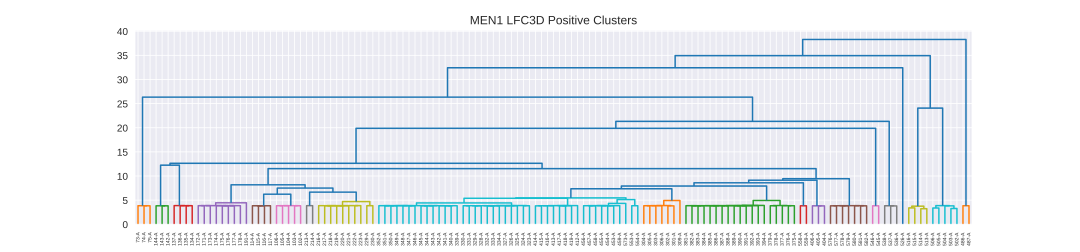

In [ ]:
# @title LFC3D Hit Clusters (Dendrogram)
display(SVG(filename=f'/content/{output_dir}/cluster_LFC3D/plots/MEN1_Meta_LFC3D_Positive_Dendrogram_p<0.001_6A.svg'))
